# DINOv2

Notebook pentru `DINOv2-Base + decoder de segmentare`.

In [5]:
!pip install -q transformers

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

from pathlib import Path
import utils

from model_builders import build_dinov2_model
from utils import (
    DiceBCELoss,
    SEED,
    benchmark_model,
    build_experiment_result_row,
    build_optimization_profile,
    build_segmentation_dataloaders,
    collect_prediction_examples,
    count_trainable_parameters,
    create_optimizer,
    create_scaler,
    create_scheduler,
    device,
    fit_segmentation_model,
    get_protocol_splits,
    load_segmentation_checkpoint,
    plot_training_history,
    prepare_model_for_optimizations,
    quantize_model_for_inference,
    run_validation_epoch,
    seed_everything,
    summarize_protocol_splits,
    visualize_prediction_examples,
)

seed_everything(SEED)
print('Device:', device)
print('Seed:', SEED)

Device: cuda
Seed: 1335


In [7]:
BASE = Path("/kaggle/input/datasets/rarescocosila/proiect-iava/dataset-iava")

utils.SEVERSTAL_ROOT = BASE / "severstal-steel-defect-detection"
utils.NEU_ROOT = BASE / "NEU-DET_data"
utils.KOLEKTOR_ROOT = BASE / "kolektor_data"

utils.TRAIN_DIR = f'{utils.SEVERSTAL_ROOT}/train_images'
utils.TRAIN_CSV = f'{utils.SEVERSTAL_ROOT}/train.csv'
utils.TEST_DIR = f'{utils.SEVERSTAL_ROOT}/test_images'

utils.build_severstal_metadata.__defaults__ = (
    utils.TRAIN_CSV,
    utils.TRAIN_DIR
)

build_severstal_metadata = utils.build_severstal_metadata

In [8]:
IMG_SIZE = 518
BATCH_SIZE = 2
EPOCHS = 6
LR = 2e-5
WEIGHT_DECAY = 1e-4
PATIENCE = 4
OPTIMIZER_NAME = 'adamw'
SCHEDULER_NAME = 'cosine'
LOSS_NAME = 'dice_bce'
NORMALIZE = 'imagenet'
REFRESH_METADATA = True
SELECTED_SOURCES = ['severstal', 'neu', 'kolektor']
QUANTIZE_CPU_BENCH = True

ACTIVE_PROFILE = build_optimization_profile(
    amp_mode='fp16',
    channels_last=True,
    compile_model=False,
    compile_mode='reduce-overhead',
    gradient_checkpointing=True,
    grad_accumulation_steps=2,
    max_grad_norm=1.0,
    ema_decay=0.999,
    persistent_workers=True,
    prefetch_factor=2,
)
ACTIVE_PROFILE

{'amp_mode': 'fp16',
 'channels_last': True,
 'compile_model': False,
 'compile_mode': 'reduce-overhead',
 'gradient_checkpointing': True,
 'grad_accumulation_steps': 2,
 'max_grad_norm': 1.0,
 'ema_decay': 0.999,
 'persistent_workers': True,
 'prefetch_factor': 2}

In [9]:
metadata, train_df, val_df, test_df = get_protocol_splits(random_state=SEED, refresh_cache=REFRESH_METADATA, cache_path="/kaggle/working/merged_metadata.csv"
)
train_df = train_df[train_df['source'].isin(SELECTED_SOURCES)].reset_index(drop=True)
val_df = val_df[val_df['source'].isin(SELECTED_SOURCES)].reset_index(drop=True)
test_df = test_df[test_df['source'].isin(SELECTED_SOURCES)].reset_index(drop=True)
display(summarize_protocol_splits(pd.concat([train_df, val_df, test_df], ignore_index=True)))
print('Train size:', len(train_df), 'Val size:', len(val_df), 'Test size:', len(test_df))

,protocol_split,source,images,defect_images,clean_images
0,train,kolektor,2097,221,1876
1,train,neu,863,863,0
2,train,severstal,10054,5333,4721
3,val,kolektor,234,25,209
4,val,neu,96,96,0
5,val,severstal,1257,666,591
6,test_final,kolektor,1004,110,894
7,test_final,neu,240,240,0
8,test_final,severstal,1257,667,590


Train size: 13014 Val size: 1587 Test size: 2501


In [10]:
train_dataset, val_dataset, train_loader, val_loader = build_segmentation_dataloaders(
    train_df=train_df,
    val_df=val_df,
    img_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    num_workers=2,
    normalize=NORMALIZE,
    persistent_workers=ACTIVE_PROFILE['persistent_workers'],
    prefetch_factor=ACTIVE_PROFILE['prefetch_factor'],
)

In [ ]:
model = build_dinov2_model()
model, opt_info = prepare_model_for_optimizations(
    model,
    channels_last=ACTIVE_PROFILE['channels_last'],
    compile_model=ACTIVE_PROFILE['compile_model'],
    compile_mode=ACTIVE_PROFILE['compile_mode'],
    gradient_checkpointing=ACTIVE_PROFILE['gradient_checkpointing'],
)
criterion = DiceBCELoss() if LOSS_NAME == 'dice_bce' else None
optimizer = create_optimizer(model, name=OPTIMIZER_NAME, lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = create_scheduler(optimizer, name=SCHEDULER_NAME, epochs=EPOCHS)
scaler = create_scaler(amp_mode=ACTIVE_PROFILE['amp_mode'])
trainable_params = count_trainable_parameters(model)
print('Trainable params:', f'{trainable_params:,}')

config.json:   0%|          | 0.00/548 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/223 [00:00<?, ?it/s]

Trainable params: 88,131,172


/kaggle/input/datasets/rarescocosila/proiect-iava/utils.py:1230: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  return GradScaler()


dinov2 train 1/6:   0%|          | 0/6507 [00:00<?, ?it/s]

/kaggle/input/datasets/rarescocosila/proiect-iava/utils.py:1240: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  return autocast(dtype=torch.float16)


dinov2 val 1/6:   0%|          | 0/794 [00:00<?, ?it/s]

dinov2 epoch 1/6 | train_loss=0.2842 train_dice=0.7286 val_loss=0.2133 val_dice=0.8685 val_iou=0.8685


dinov2 train 2/6:   0%|          | 0/6507 [00:00<?, ?it/s]

...

dinov2 val 5/6:   0%|          | 0/794 [00:00<?, ?it/s]

dinov2 epoch 5/6 | train_loss=0.1049 train_dice=0.8679 val_loss=0.1043 val_dice=0.8693 val_iou=0.8668


dinov2 train 6/6:   0%|          | 0/6507 [00:00<?, ?it/s]

dinov2 val 6/6:   0%|          | 0/794 [00:00<?, ?it/s]

dinov2 epoch 6/6 | train_loss=0.1020 train_dice=0.8714 val_loss=0.1027 val_dice=0.8706 val_iou=0.8675


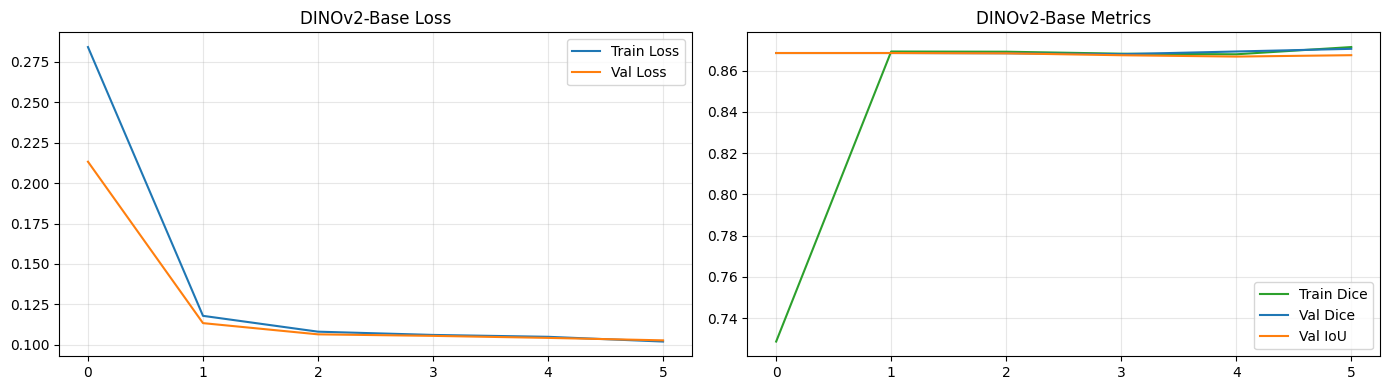

In [12]:
history = fit_segmentation_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    epochs=EPOCHS,
    scheduler=scheduler,
    scaler=scaler,
    patience=PATIENCE,
    checkpoint_path='dinov2_merged_best.pth',
    model_name='dinov2',
    amp_mode=ACTIVE_PROFILE['amp_mode'],
    grad_accumulation_steps=ACTIVE_PROFILE['grad_accumulation_steps'],
    max_grad_norm=ACTIVE_PROFILE['max_grad_norm'],
    use_channels_last=ACTIVE_PROFILE['channels_last'],
    ema_decay=ACTIVE_PROFILE['ema_decay'],
)
fig = plot_training_history(history, title_prefix='DINOv2-Base')
fig.savefig('dinov2_merged_history.png', dpi=150)
plt.show()

In [13]:
load_segmentation_checkpoint(model, 'dinov2_merged_best.pth', prefer_ema=True)
test_loader = build_segmentation_dataloaders(
    train_df=train_df.head(8),
    val_df=test_df,
    img_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    num_workers=0,
    normalize=NORMALIZE,
)[3]
test_metrics = run_validation_epoch(
    model=model,
    dataloader=test_loader,
    criterion=criterion,
    scaler=scaler,
    amp_mode=ACTIVE_PROFILE['amp_mode'],
    use_channels_last=ACTIVE_PROFILE['channels_last'],
)
test_metrics

val:   0%|          | 0/1251 [00:00<?, ?it/s]

/kaggle/input/datasets/rarescocosila/proiect-iava/utils.py:1240: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  return autocast(dtype=torch.float16)


{'loss': 0.08726855156366987,
 'dice': 0.8952935502397642,
 'iou': 0.8922082224338175}

In [14]:
gpu_benchmark = benchmark_model(model, input_shape=(1, 3, IMG_SIZE, IMG_SIZE), runs=10, warmup=3)
result_row = build_experiment_result_row(
    model_name='dinov2_base_merged',
    history=history,
    benchmark=gpu_benchmark,
    trainable_params=trainable_params,
    optimizer_name=OPTIMIZER_NAME,
    scheduler_name=SCHEDULER_NAME,
    loss_name=LOSS_NAME,
    optimization_profile={**ACTIVE_PROFILE, **opt_info},
)
result_row.update({f'test_{key}': value for key, value in test_metrics.items()})
results = [result_row]
if QUANTIZE_CPU_BENCH:
    quantized_model = quantize_model_for_inference(model)
    quant_benchmark = benchmark_model(quantized_model, input_shape=(1, 3, IMG_SIZE, IMG_SIZE), runs=10, warmup=3, benchmark_device='cpu')
    quant_row = result_row.copy()
    quant_row['model'] = 'dinov2_base_merged_quantized_cpu'
    quant_row.update(quant_benchmark)
    quant_row['opt_quantized_cpu'] = True
    results.append(quant_row)
results_df = pd.DataFrame(results)
results_df.to_csv('dinov2_merged_results.csv', index=False)
results_df

,model,epochs_ran,best_epoch,best_val_dice,best_val_iou,best_val_loss,final_train_loss,final_val_loss,optimizer,scheduler,...,opt_grad_accumulation_steps,opt_max_grad_norm,opt_ema_decay,opt_persistent_workers,opt_prefetch_factor,opt_gradient_checkpointing_modules,test_loss,test_dice,test_iou,opt_quantized_cpu
0,dinov2_base_merged,6,6,0.870578,0.867492,0.102749,0.102003,0.102749,adamw,cosine,...,2,1.0,0.999,True,2,[backbone],0.087269,0.895294,0.892208,NaN
1,dinov2_base_merged_quantized_cpu,6,6,0.870578,0.867492,0.102749,0.102003,0.102749,adamw,cosine,...,2,1.0,0.999,True,2,[backbone],0.087269,0.895294,0.892208,True


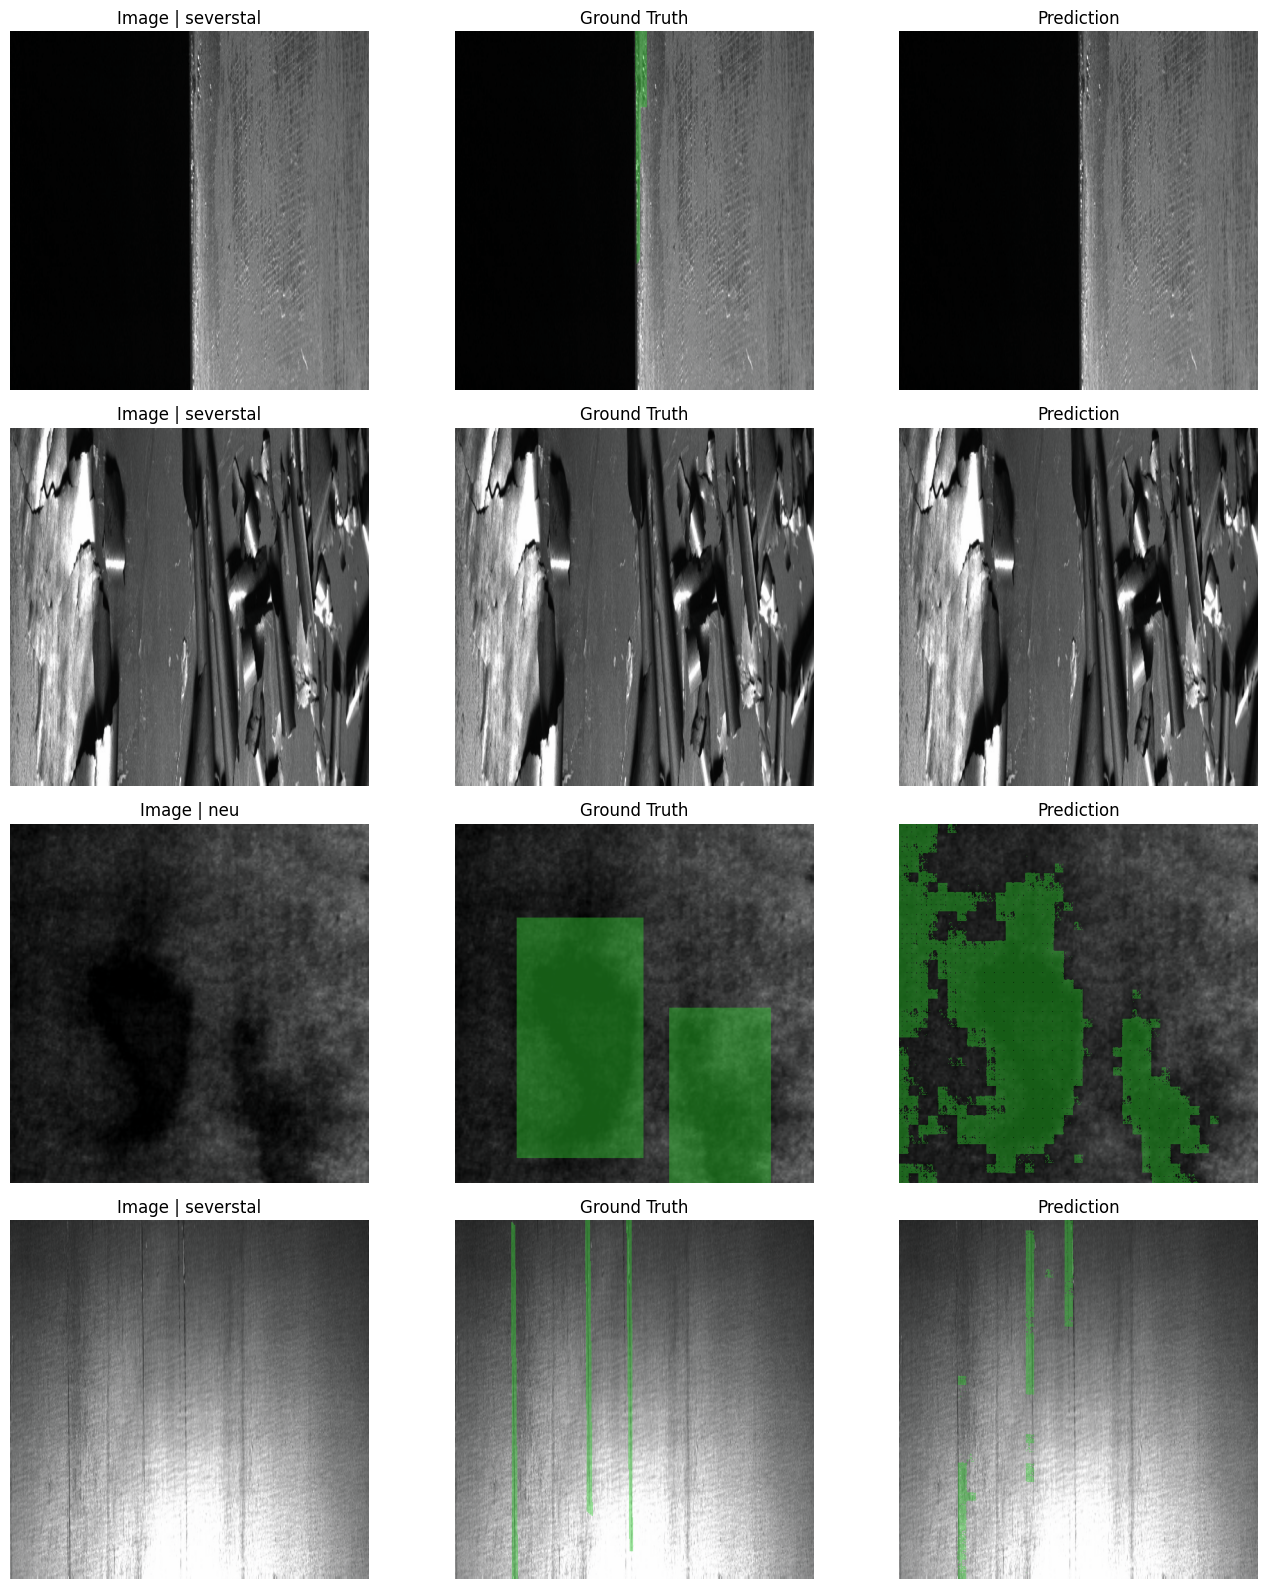

In [29]:
test_dataset_with_meta = build_segmentation_dataloaders(
    train_df=train_df.head(8),
    val_df=test_df,
    img_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    num_workers=0,
    normalize=NORMALIZE,
    return_metadata=True,
)[1]
examples = collect_prediction_examples(model, test_dataset_with_meta, num_samples=4, normalize=NORMALIZE)
fig = visualize_prediction_examples(examples, max_examples=4)
fig.savefig('dinov2_test_predictions.png', dpi=150)
plt.show()